# 10 -- Enrichment Plot Families: Bar, Lollipop, Heatmap, Cluster Heatmap, Share Distribution

venn-diagram-lab ships five complementary plots for the *same* underlying
pairwise statistics. Each emphasises a different aspect of the data, and
the PDF report uses them together to give a complete picture. This
notebook renders all five on one dataset side-by-side and explains which
to pick when.

**Audience:** researchers choosing between visualisations for a paper
or talk.

**The five plot families:**

1. **Bar chart** -- vertical bars per pair, ranked, easy to compare absolute
   magnitudes (`-log10(FDR)` or fold enrichment).
2. **Lollipop chart** -- same data as bar but with point markers; cleaner
   for dense pair lists and emphasises rank order.
3. **Heatmap** -- square matrix of pairs; reveals symmetric structure and
   block patterns at a glance.
4. **Cluster heatmap** -- adds UPGMA-reordered axes + dendrograms; surfaces
   which catalogs form natural groups.
5. **Item Share Distribution** -- histogram of items by *how many* sets they
   appear in; reveals the core/accessory split.


In [1]:
from IPython.display import display

import venn_diagram_lab as vdl

ds = vdl.load_sample('dataset_real_cancer_drivers_4')
result = vdl.analyze(ds, model='auto')
print(f'venn-diagram-lab {vdl.__version__}')
print('Sets:', result.dataset.set_names)
print('Set sizes:', dict(result.set_sizes))

venn-diagram-lab 2.2.3
Sets: ['Vogelstein', 'COSMIC_CGC', 'OncoKB', 'IntOGen']
Set sizes: {'Vogelstein': 138, 'COSMIC_CGC': 581, 'OncoKB': 1231, 'IntOGen': 633}


## 1. Bar chart -- ranked magnitudes

Bars are the most familiar encoding for magnitude. Use the bar chart when
the audience needs to compare absolute values across pairs (e.g. *Vogelstein /
COSMIC_CGC is twice as enriched as Vogelstein / IntOGen*). Default metric
is `-log10(FDR)`; significance markers (`***`/`**`/`*`) sit at the bar tip.


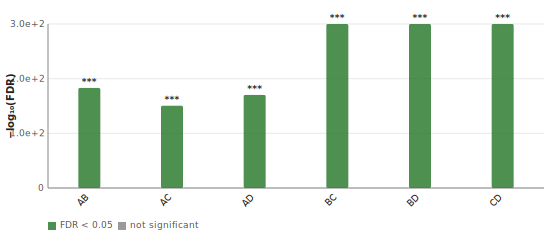

In [2]:
from venn_diagram_lab.render.svg import render_enrichment_bar_svg

display(render_enrichment_bar_svg(result))

## 2. Lollipop chart -- cleaner for dense pair lists

Lollipops replace the bar with a stem + circle marker. The reduced ink
makes long lists (10+ pairs) more legible without sacrificing the rank
information. Same metric options as bar.


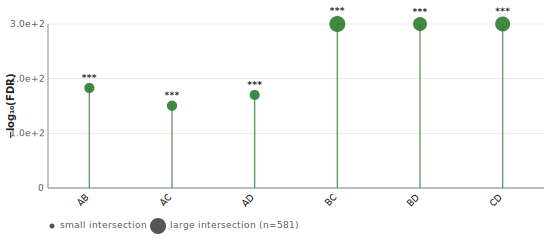

In [3]:
from venn_diagram_lab.render.svg import render_enrichment_lollipop_svg

display(render_enrichment_lollipop_svg(result))

## 3. Heatmap -- symmetric matrix view

The heatmap shows the full N x N similarity matrix (Jaccard by default).
Strengths: surfaces symmetric structure instantly, no labelling needed for
the diagonal, and the colour gradient makes outlier pairs pop. Weakness:
harder to read exact values without hover tooltips.


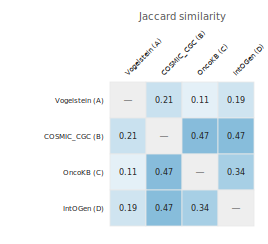

In [4]:
from venn_diagram_lab.render.svg import render_cluster_heatmap_svg

# Without dendrograms -- pure heatmap, axes in input order.
display(render_cluster_heatmap_svg(
    result,
    show_row_dendrogram=False,
    show_col_dendrogram=False,
))

## 4. Cluster heatmap -- which catalogs group together?

Adding row + column dendrograms (UPGMA / `linkage='average'` by default)
reorders both axes so similar sets sit next to each other. The L-shaped
dendrogram overlays show the merge order. Use this when the question
shifts from *how similar is pair X?* to *which catalogs cluster?*


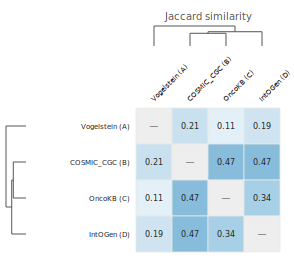

In [5]:
display(render_cluster_heatmap_svg(
    result,
    linkage='average',
    show_row_dendrogram=True,
    show_col_dendrogram=True,
))

## Decision table

| Plot | Use when... | Avoid when... |
|------|------------|---------------|
| Bar | You need exact magnitudes per pair | >15 pairs (gets crowded) |
| Lollipop | Dense pair list, rank matters | Audience expects classic bars |
| Heatmap | Symmetric structure should pop visually | Exact values critical |
| Cluster heatmap | Audience needs to see catalog groupings | Set count < 4 (no cluster signal) |
| Share distribution | You want to discuss the core/accessory split | Set count = 2 (degenerate) |


## Switching the metric: fold enrichment

Both bar and lollipop accept a `metric` keyword. Default is
`'neglog10fdr'` (significance scale); switching to `'foldEnrichment'`
(effect-size scale) tells a different story for the same pairs.
Use FE when the audience cares about *how big* the over-representation
is rather than *how confident* we are it isn't noise.


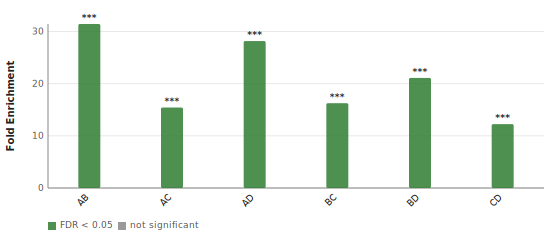

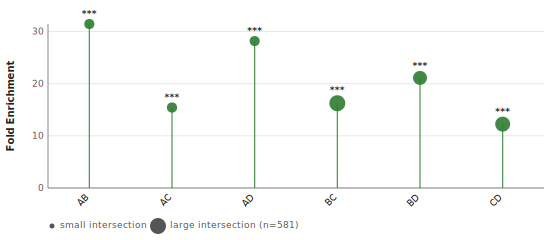

In [6]:
display(render_enrichment_bar_svg(result, metric='foldEnrichment'))
display(render_enrichment_lollipop_svg(result, metric='foldEnrichment'))

## 5. Item Share Distribution -- the 5th, complementary plot

The other four plots all summarise *pairwise* statistics. The share
distribution asks a different question: *across the entire dataset,
how many items appear in exactly 1, 2, 3, ..., N sets?* The result
is a single histogram that reveals the **core/accessory split**:
tall left bar = mostly unique items (low overlap); tall right bar =
mostly shared items (high consensus).

It is computed on the `Dataset` (not the `RegionResult`) because it
only depends on item membership, not on which Venn model was chosen.


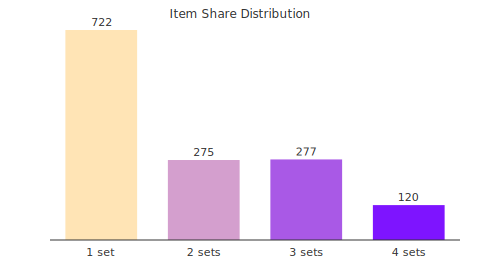

In [7]:
from venn_diagram_lab.render.svg import render_share_distribution_svg

display(render_share_distribution_svg(ds))

## How the PDF report uses each plot

All five plots appear in the multi-page report generated by
`result.to_pdf_report()` (see notebook 07). The placement mirrors a
narrative arc:

1. **Page 1 -- Overview**: set sizes + share distribution (core vs accessory).
2. **Page 2 -- Visual summary**: Venn + UpSet (set membership).
3. **Page 3+ -- Pairwise stats**: Jaccard / Dice / Enrichment tables, then
   the bar, lollipop, and cluster heatmap plots in that order.
4. **Final page**: Network + methodology explanations.

Each plot complements the next: the table gives exact numbers, the bar
ranks them, the lollipop densifies, the cluster heatmap exposes groups,
and the share distribution closes the loop by showing how the universe
as a whole partitions.


## Next steps

- [`05_statistics_deep_dive.ipynb`](05_statistics_deep_dive.ipynb) -- the formulae underlying every plot here
- [`07_pdf_reports.ipynb`](07_pdf_reports.ipynb) -- bundle every plot into a single PDF
